# Day 2b: Xenium as a `SpatialData` object (optional)

The main Day 2 notebook keeps the data in a lean `AnnData` table. Here we instead load the section as a **`SpatialData`** object, which aligns the **cell boundaries** (shapes), the **transcripts** (points), the **image**, and the **cell table** in one coordinate system, and we render it with **`spatialdata-plot`** (no manual matplotlib).

This needs `spatialdata-plot` (and, for the interactive step, `napari` + `napari-spatialdata`). Run it with the **Python (spatialdata)** kernel from `environment-spatialdata.yml`, or with the course kernel (which also ships `spatialdata-plot`). Static rendering runs on the server; the napari step is local only.

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

import spatialdata as sd
import spatialdata_io
import spatialdata_plot  # registers the .pl plotting accessor
from spatialdata import bounding_box_query, get_extent

def _data_dir():
    env = os.environ.get('SPATIAL_COURSE_DATA')
    if env:
        return Path(env)
    shared = Path('/home/shared/spatial_course_data')
    if shared.exists():
        return shared
    return Path.home() / 'spatial_course_data'

XEN = _data_dir() / 'xenium_kidney'
print('data:', XEN)

data: /home/robin/spatial_course_data/xenium_kidney


## 1. Load the section as `SpatialData`

> **Method note: lazy and multimodal.** `spatialdata_io.xenium` reads the bundle into one object. We keep the **boundaries**, **transcripts**, and **cell table**, and skip the large morphology image to stay light (set `morphology_focus=True` locally to add it; it loads lazily). The transcripts come in as a lazy points table, so building the object is cheap.

In [2]:
sdata = spatialdata_io.xenium(
    str(XEN),
    cells_boundaries=True, nucleus_boundaries=True,
    transcripts=True, cells_as_circles=False,
    morphology_mip=False, morphology_focus=False,
)
sdata

SpatialData object
├── Labels
│     ├── 'cell_labels': DataTree[yx] (13921, 42636), (6960, 21318), (3480, 10659), (1740, 5329), (870, 2664)
│     └── 'nucleus_labels': DataTree[yx] (13921, 42636), (6960, 21318), (3480, 10659), (1740, 5329), (870, 2664)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (97560, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (97560, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (97560, 377)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

The object holds **shapes** (`cell_boundaries`, `nucleus_boundaries`), **points** (`transcripts`), and a **table** (the cell × gene `AnnData`), all in one `global` coordinate system. A spatial crop therefore pulls the matching polygons, molecules, and cells together.

## 2. Crop a field of view and render the boundaries

We crop the whole object with `bounding_box_query` and render the segmentation polygons with `spatialdata-plot`. The `global` coordinate system here is in **pixels** (the Xenium pixel size is ~0.21 um), so we take a window around the centre of the section.

/opt/conda/envs/spatial-course/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


381 cells in the crop


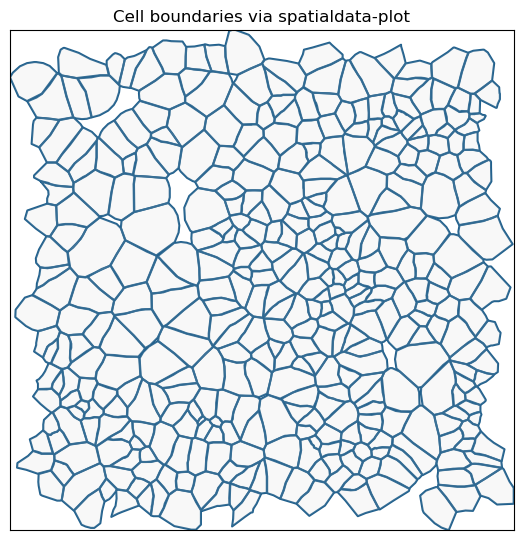

In [3]:
ext = get_extent(sdata['cell_boundaries'], coordinate_system='global')
cx = (ext['x'][0] + ext['x'][1]) / 2
cy = (ext['y'][0] + ext['y'][1]) / 2
hw = 600  # half-width in global (pixel) units, ~125 um

crop = bounding_box_query(
    sdata, axes=('x', 'y'),
    min_coordinate=[cx - hw, cy - hw], max_coordinate=[cx + hw, cy + hw],
    target_coordinate_system='global', filter_table=False,
)
print(f"{len(crop['cell_boundaries'])} cells in the crop")

ax = plt.subplots(figsize=(6.5, 6.5))[1]
crop.pl.render_shapes('cell_boundaries', outline_alpha=1.0, fill_alpha=0.15,
                      outline_color='#1f5f8c').pl.show(ax=ax, colorbar=False)
ax.set_title('Cell boundaries via spatialdata-plot')
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 3. Render the molecules (points element) over the boundaries

The transcripts live in `sdata['transcripts']` as a points element. We render them with `render_points`, colouring a few marker genes by `feature_name` (using `groups=` to highlight just those), chained onto the boundary render so both come from the **same `SpatialData` crop**.

WARNING  render_points: Groups ['LRP2', 'NPHS2', 'SLC12A1'] were not found in 'feature_name' and will be ignored.  
         Available categories: ['CD3D', 'PECAM1', 'UMOD'].                                                         


/opt/conda/envs/spatial-course/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/opt/conda/envs/spatial-course/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/envs/spatial-course/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:1384: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(


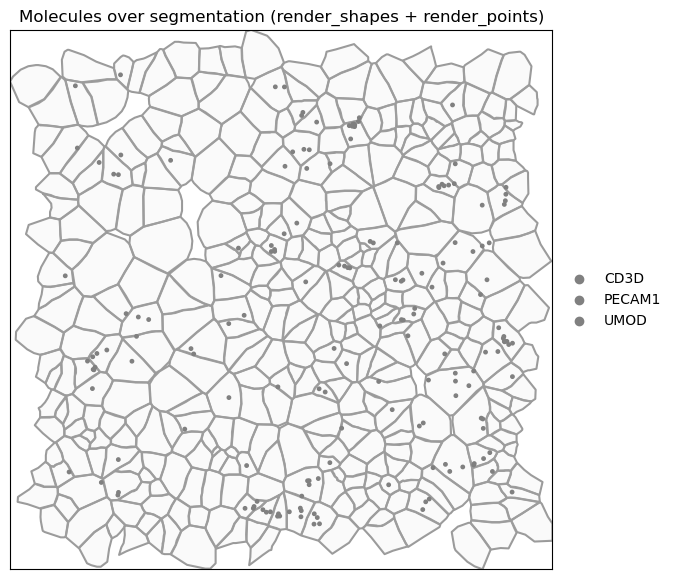

In [4]:
markers = ['UMOD', 'LRP2', 'PECAM1', 'NPHS2', 'CD3D', 'SLC12A1']

ax = plt.subplots(figsize=(7, 7))[1]
(
    crop
    .pl.render_shapes('cell_boundaries', outline_alpha=1.0, fill_alpha=0.1, outline_color='#999999')
    .pl.render_points('transcripts', color='feature_name', groups=markers, size=6)
    .pl.show(ax=ax)
)
ax.set_title('Molecules over segmentation (render_shapes + render_points)')
ax.set_xticks([]); ax.set_yticks([])
plt.show()

> **Reading it.** Each coloured dot is a decoded transcript of a marker gene placed at its `(x, y)`; the outlines are the default (nucleus + ~15 um expansion) segmentation. Most molecules fall inside one polygon, but near a boundary the assignment is a guess. Everything was rendered straight from the `SpatialData` object, so the polygons and molecules share one coordinate system.

## 4. Optional: explore interactively in napari (local only)

> `napari-spatialdata` opens the whole object (image, shapes, points, table) in an interactive viewer where you can pan, zoom, and toggle layers. It needs a desktop session and the `napari` + `napari-spatialdata` packages (in `environment-spatialdata.yml`), so it does not run on the headless lab server.

In [5]:
try:
    from napari_spatialdata import Interactive
    # On your own machine, uncomment to launch the viewer:
    # Interactive(sdata).run()
    print('napari-spatialdata is available: run  Interactive(sdata).run()  on a desktop session.')
except Exception as e:
    print('napari-spatialdata not available here (run locally with the spatialdata env):', type(e).__name__)

napari-spatialdata not available here (run locally with the spatialdata env): ModuleNotFoundError


### Recap

`SpatialData` is the right container when you need the image, segmentation, and molecules together; `spatialdata-plot` renders its elements (`render_shapes`, `render_points`, `render_images`), and `napari-spatialdata` explores them interactively. For the table-level workflow (QC, clustering, typing, neighbourhood statistics) the lean `AnnData` path in `02_solutions.ipynb` is lighter and is what we use for the rest of Day 2.